

# Decision Trees

## Table Of Contents 


- Import the Required Libraries
- Read the CSV File 
- PreProcessing the Data 
- Modeling 
- Prediction


## Import the Needed Libraries



In [2]:
import numpy as np 
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

## Reading the Csv File

In [3]:
my_data = pd.read_csv("drug200.csv", delimiter=",")
my_data[0:5]

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [4]:
my_data.shape


(200, 6)

<div href="pre-processing">
    <h2>Pre-processing</h2>
</div>


Utilizing <b>my_data</b> as the Drug.csv dataset assessed by pandas, declare the following variables: <br>

<ul>
    <li> <b>X</b> as the <b>Feature Matrix</b>(my_data data)</li> 
    <li> <b>y</b> as the <b>response vector</b>(target)</li>
</ul>

In [5]:
X = my_data[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values
X[0:5]


array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

In [6]:
y = my_data["Drug"]
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

As you might surmise, there are categorical variables in the dataset. Variables like **Sex** or **BP** are examples of categorical variables. Unfortunately, Sklearn Decision Trees will not accept categorical variables directly. So we** can still convert these to numerical values instead by using **pandas.get_dummies()**
to convert the categorical variable into dummy/indicator variables.

In [7]:
from sklearn import preprocessing
le_sex = preprocessing.LabelEncoder()
le_sex.fit(['F','M'])
X[:,1] = le_sex.transform(X[:,1]) 


le_BP = preprocessing.LabelEncoder()
le_BP.fit([ 'LOW', 'NORMAL', 'HIGH'])
X[:,2] = le_BP.transform(X[:,2])


le_Chol = preprocessing.LabelEncoder()
le_Chol.fit([ 'NORMAL', 'HIGH'])
X[:,3] = le_Chol.transform(X[:,3]) 

X[0:5]


array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

<hr>

<div id="setting_up_tree">
    <h2>Setting up the Decision Tree</h2>
    We will apply train/test split to our decision tree. Let's import train_test_split from sklearn.cross_validation. 
</div>


In [8]:
from sklearn.model_selection import train_test_split

The function called <b> train_test_split </b> will take training set and testing set (4) parameters, and we will name them :<br> 
* X_trainset, 
* X_testset, 
* y_trainset, 
* y_testset,<br> <br>
Along with the original <b>train_test_split</b> function, you will need to enter the <b>X</b> and <b>y</b> arrays required prior to testing, <b>test_size</b> (which represents the ratio of the testing data set), and <b>random_state</b> ensure we obtain the same splits.

In [9]:
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.3, random_state=3)

<hr>

<div id="modeling">
    <h2>Modeling</h2>
    We will first make an instance of the DecisionTreeClassifier called drugTree.
    Inside the classifier, specify criterion="entropy" so we can see the information gain of each node.
</div>


In [12]:
drugTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
drugTree # it shows the default parameters

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Next, we will fit the data using both the training feature matrix X_trainset and the training response vector y_trainset

In [13]:
drugTree.fit(X_trainset,y_trainset)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<hr>

<div id="prediction">
    <h2>Prediction</h2>
Let's predict the target values based on the testing data and save it in a variable name <b>predTree</b>.

</div>


In [14]:
predTree = drugTree.predict(X_testset)

In [15]:
print (predTree [0:5])
print (y_testset [0:5])


['drugY' 'drugX' 'drugX' 'drugX' 'drugX']
40     drugY
51     drugX
139    drugX
197    drugX
170    drugX
Name: Drug, dtype: object


<hr>

<div id="evaluation">
    <h2>Evaluation</h2>
    Next, let's import <b>metrics</b> from sklearn and check the accuracy of our model.
</div>


In [16]:
from sklearn import metrics
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_testset, predTree))

DecisionTrees's Accuracy:  0.9833333333333333


**Accuracy classification score** calculates subset accuracy, which requires the predicted set of labels for a sample to be exactly the same as the corresponding set of labels in y_true. In multi-label classification, this function will return the subset accuracy. The subset accuracy = 1.0 if the entire predicted set of labels for a sample is exactly the same as the true set of labels and = 0.0 otherwise.

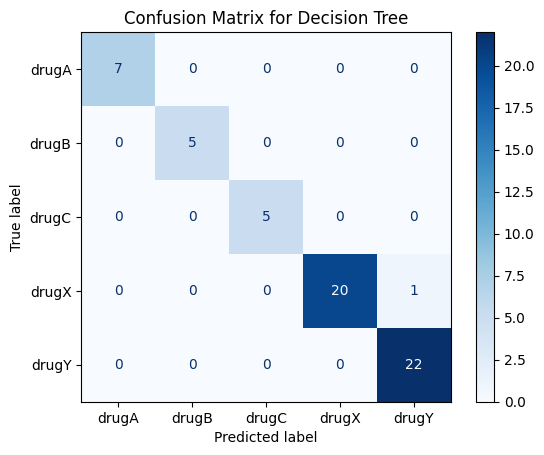

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_testset, predTree, labels=drugTree.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=drugTree.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix for Decision Tree")
plt.show()
